# Cuaderno de Ejercicios: Introducción a Pandas
## Dataset: Flujos Migratorios Mixtos hacia Europa 2024

> Este cuaderno usa datos reales de la OIM (Organización Internacional para las Migraciones)
> sobre flujos migratorios mixtos hacia países europeos durante 2024.
> El dataset contiene información sobre llegadas mensuales por país de origen, país de destino y ruta.

---

## 📋 Instrucciones Generales

Este cuaderno contiene ejercicios prácticos para aprender Pandas utilizando datos reales sobre flujos migratorios hacia Europa. Los ejercicios están organizados por nivel de dificultad y cubren los conceptos fundamentales de la librería.

**Dataset**: `DTM_Mixed Migration Flows to Europe_Yearly_2024_1.xlsx`
**Hoja de trabajo**: `First_Arrival_Countries_CoO`

> 🔑 **Columnas del dataset:**
> | Columna | Tipo | Descripción |
> |---------|------|-------------|
> | `Date` | datetime | Fecha del registro (último día del mes) |
> | `Year` | int | Año (2024) |
> | `Month` | int | Mes (1-12) |
> | `ISO3 - Country of origin` | str | Código ISO3 del país de origen |
> | `ISO3 - Country of arrival` | str | Código ISO3 del país de llegada |
> | `Route` | str | Ruta migratoria utilizada |
> | `Arrivals` | int | Número de llegadas registradas |
> | `Source` | str | Fuente de los datos |

---

## 🎯 Objetivos de Aprendizaje

Al completar estos ejercicios serás capaz de:
- Cargar y explorar datos con Pandas
- Acceder y filtrar información
- Manipular y transformar datos
- Realizar análisis agrupados
- Manejar valores nulos

---

## 📚 Sección 1: Carga y Exploración Inicial

### Ejercicio 1.1: Importar librerías y cargar datos

> Recuerda: siempre empezamos importando las librerías necesarias y cargando los datos.

In [26]:
# 'import pandas as pd' carga la librería Pandas y le asigna el alias 'pd'.
# Este alias es una convención universal: todo el mundo usa 'pd' para referirse a Pandas.
import pandas as pd

# pd.read_excel() lee un archivo Excel y lo convierte en un DataFrame.
# - El primer argumento es la ruta al archivo .xlsx
# - sheet_name indica QUÉ HOJA del Excel queremos leer
# - Si no se especifica sheet_name, se lee la primera hoja por defecto
df = pd.read_excel(
    r".\data\DTM_Mixed Migration Flows to Europe_Yearly_2024_1.xlsx",
    sheet_name="First_Arrival_Countries_CoO"
)

# .head() muestra las primeras 5 filas por defecto.
# Es lo primero que hacemos para verificar que los datos se cargaron correctamente.
df.head()

,Date,Year,Month,ISO3 - Country of origin,ISO3 - Country of arrival,Route,Arrivals,Source
0,2024-01-31,2024,1,BGD,MLT,CMR,7,"Maltese Minitry of Home Affairs, Security and ..."
1,2024-01-31,2024,1,EGY,MLT,CMR,1,"Maltese Minitry of Home Affairs, Security and ..."
2,2024-01-31,2024,1,PAK,MLT,CMR,22,"Maltese Minitry of Home Affairs, Security and ..."
3,2024-01-31,2024,1,SDN,MLT,CMR,1,"Maltese Minitry of Home Affairs, Security and ..."
4,2024-01-31,2024,1,SYR,MLT,CMR,4,"Maltese Minitry of Home Affairs, Security and ..."


### Ejercicio 1.2: Información básica del dataset

> Antes de analizar datos, siempre hay que entender su estructura: cuántas filas y columnas hay, qué tipo de datos tiene cada columna, y si hay valores faltantes.

In [27]:
# .info() muestra un resumen completo del DataFrame:
#   - Número total de filas (entries)
#   - Nombre y tipo de dato de cada columna
#   - Cuántos valores no nulos hay por columna (para detectar datos faltantes)
#   - Uso total de memoria
df.info()

# .shape devuelve una tupla (filas, columnas).
# Es un atributo (sin paréntesis), no un método.
print(f"\nFilas y columnas: {df.shape}")
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas")

# .columns devuelve los nombres de todas las columnas.
# Útil para copiar nombres exactos al escribir filtros o selecciones.
print(f"\nColumnas del DataFrame:")
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1689 entries, 0 to 1688
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       1689 non-null   datetime64[us]
 1   Year                       1689 non-null   int64         
 2   Month                      1689 non-null   int64         
 3   ISO3 - Country of origin   1689 non-null   str           
 4   ISO3 - Country of arrival  1689 non-null   str           
 5   Route                      1689 non-null   str           
 6   Arrivals                   1689 non-null   int64         
 7   Source                     1689 non-null   str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 105.7 KB

Filas y columnas: (1689, 8)
El dataset tiene 1689 filas y 8 columnas

Columnas del DataFrame:
['Date', 'Year', 'Month', 'ISO3 - Country of origin', 'ISO3 - Country of arrival', 'Route', 'Arrivals', 'Source']

### Ejercicio 1.3: Estadísticas descriptivas

In [28]:
# .describe() genera estadísticas descriptivas de las columnas numéricas:
#   count = número de valores no nulos
#   mean  = media (promedio)
#   std   = desviación estándar
#   min   = valor mínimo
#   25%/50%/75% = percentiles (cuartiles)
#   max   = valor máximo
df.describe()

# .mean() calcula la media de una columna numérica.
# Aquí vemos el promedio de llegadas por registro.
print(f"\nMedia de llegadas: {df['Arrivals'].mean():.2f}")

# .max() devuelve el valor máximo de la columna.
# Útil para identificar los picos o registros extremos.
print(f"Máximo de llegadas: {df['Arrivals'].max()}")


Media de llegadas: 123.69
Máximo de llegadas: 4232


---

## 🔍 Sección 2: Acceso y Selección de Datos

### Ejercicio 2.1: Seleccionar columnas

In [29]:
# Para seleccionar VARIAS columnas, pasamos una LISTA de nombres dentro de corchetes.
# Nota el doble corchete: df[['col1', 'col2', 'col3']]
#   - El corchete exterior: operador de acceso del DataFrame
#   - El corchete interior: define la lista de columnas
# El resultado es un nuevo DataFrame con solo esas columnas.
df_seleccion = df[['ISO3 - Country of origin', 'ISO3 - Country of arrival', 'Arrivals']]

# .head(10) muestra las primeras 10 filas de esta selección.
df_seleccion.head(10)

,ISO3 - Country of origin,ISO3 - Country of arrival,Arrivals
0,BGD,MLT,7
1,EGY,MLT,1
2,PAK,MLT,22
3,SDN,MLT,1
4,SYR,MLT,4
5,BGD,MLT,7
6,EGY,MLT,1
7,ERI,MLT,8
8,ETH,MLT,2
9,GHA,MLT,3


### Ejercicio 2.2: Acceso por posición

In [30]:
# .iloc[] accede por POSICIÓN numérica (integer-location).
# iloc[filas, columnas] donde los rangos son EXCLUSIVOS (como en Python normal).
# iloc[:20, :4] = primeras 20 filas (posiciones 0-19), primeras 4 columnas (posiciones 0-3).
print("=== Con iloc (primeras 20 filas, 4 primeras columnas) ===")
display(df.iloc[:20, :4])

# .loc[] accede por ETIQUETAS (label-location).
# loc[filas, columnas] donde los rangos son INCLUSIVOS (incluye el último valor).
# loc[10:15] = filas con índice 10 a 15 (ambos incluidos = 6 filas).
# Las columnas se especifican por nombre.
print("\n=== Con loc (filas 10-15, columnas Route y Arrivals) ===")
df.loc[10:15, ['Route', 'Arrivals']]

=== Con iloc (primeras 20 filas, 4 primeras columnas) ===


,Date,Year,Month,ISO3 - Country of origin
0,2024-01-31,2024,1,BGD
1,2024-01-31,2024,1,EGY
2,2024-01-31,2024,1,PAK
3,2024-01-31,2024,1,SDN
4,2024-01-31,2024,1,SYR
5,2024-02-29,2024,2,BGD
6,2024-02-29,2024,2,EGY
7,2024-02-29,2024,2,ERI
8,2024-02-29,2024,2,ETH
9,2024-02-29,2024,2,GHA



=== Con loc (filas 10-15, columnas Route y Arrivals) ===


,Route,Arrivals
10,CMR,11
11,CMR,1
12,CMR,1
13,CMR,2
14,CMR,25
15,CMR,1


### Ejercicio 2.3: Acceso a filas específicas

In [31]:
# .loc[100] accede a la fila cuya ETIQUETA de índice es 100.
# Con corchete simple devuelve una Serie (datos de esa fila en vertical).
print("=== Fila con índice 100 (loc) ===")
display(df.loc[100])

# .iloc[50] accede a la fila en la POSICIÓN 50 (la fila número 51, contando desde 0).
# En este dataset, como el índice es 0,1,2,..., loc[50] e iloc[50] dan el mismo resultado.
# Pero si el índice estuviera desordenado o fuera texto, serían diferentes.
print("\n=== Fila en posición 50 (iloc) ===")
df.iloc[50]

=== Fila con índice 100 (loc) ===


Date                                      2024-03-31 00:00:00
Year                                                     2024
Month                                                       3
ISO3 - Country of origin                                  GMB
ISO3 - Country of arrival                                 ITA
Route                                                     CMR
Arrivals                                                  280
Source                       Italian Ministry of the Interior
Name: 100, dtype: object


=== Fila en posición 50 (iloc) ===


Date                                      2024-01-31 00:00:00
Year                                                     2024
Month                                                       1
ISO3 - Country of origin                                  SEN
ISO3 - Country of arrival                                 ITA
Route                                                     CMR
Arrivals                                                   10
Source                       Italian Ministry of the Interior
Name: 50, dtype: object

---

## 🎯 Sección 3: Filtrado de Datos

### Ejercicio 3.1: Filtrado simple

In [32]:
# Filtrado: seleccionamos solo las filas que cumplen una condición.
# df[condición] crea una "máscara booleana" (True/False por fila)
# y devuelve solo las filas donde la condición es True.
# Aquí filtramos: país de llegada == 'ESP' (España).
df_espana = df[df['ISO3 - Country of arrival'] == 'ESP']

# Mostramos las primeras filas del resultado filtrado.
display(df_espana.head())

# len() cuenta el número de filas del DataFrame filtrado.
# También se puede usar .shape[0] o len(df_espana.index).
print(f"\nRegistros de llegadas a España: {len(df_espana)}")

,Date,Year,Month,ISO3 - Country of origin,ISO3 - Country of arrival,Route,Arrivals,Source
882,2024-01-31,2024,1,BEN,ESP,WMR,1,European Border and Coast Guard Agency
883,2024-01-31,2024,1,BFA,ESP,WAAR,12,European Border and Coast Guard Agency
884,2024-01-31,2024,1,BGD,ESP,WAAR,1,European Border and Coast Guard Agency
885,2024-01-31,2024,1,BGD,ESP,WMR,11,European Border and Coast Guard Agency
886,2024-01-31,2024,1,CAF,ESP,WAAR,3,European Border and Coast Guard Agency



Registros de llegadas a España: 523


### Ejercicio 3.2: Filtrado con múltiples condiciones

In [33]:
# Filtrado con VARIAS condiciones usando & (AND).
# Cada condición DEBE ir entre paréntesis para que Python entienda la prioridad.
# & = AND → ambas condiciones deben ser True
# | = OR  → al menos una debe ser True
# ~ = NOT → invierte la condición
df_siria_italia = df[
    (df['ISO3 - Country of origin'] == 'SYR') &
    (df['ISO3 - Country of arrival'] == 'ITA')
]

display(df_siria_italia.head())

# .sum() sobre la columna 'Arrivals' del resultado filtrado
# nos da el TOTAL de llegadas de sirios a Italia.
total = df_siria_italia['Arrivals'].sum()
print(f"\nTotal de llegadas de Siria a Italia: {total}")

,Date,Year,Month,ISO3 - Country of origin,ISO3 - Country of arrival,Route,Arrivals,Source
52,2024-01-31,2024,1,SYR,ITA,CMR,411,Italian Ministry of the Interior
81,2024-02-29,2024,2,SYR,ITA,CMR,353,Italian Ministry of the Interior
119,2024-03-31,2024,3,SYR,ITA,CMR,1320,Italian Ministry of the Interior
156,2024-04-30,2024,4,SYR,ITA,CMR,376,Italian Ministry of the Interior
197,2024-05-31,2024,5,SYR,ITA,CMR,660,Italian Ministry of the Interior



Total de llegadas de Siria a Italia: 12550


### Ejercicio 3.3: Filtrado con isin

In [34]:
# .isin() filtra por MÚLTIPLES valores en una misma columna.
# Es más limpio que escribir (col == 'SYR') | (col == 'AFG') | (col == 'IRQ').
# Recibe una lista de valores y devuelve True donde la columna coincida con alguno.
df_filtrado = df[df['ISO3 - Country of origin'].isin(['SYR', 'AFG', 'IRQ'])]

# .groupby() agrupa las filas por país de origen y .sum() suma las llegadas de cada grupo.
# El resultado es una Serie con el total de llegadas por cada país.
llegadas_por_origen = df_filtrado.groupby('ISO3 - Country of origin')['Arrivals'].sum()
print("Llegadas totales por país de origen:")
print(llegadas_por_origen)

Llegadas totales por país de origen:
ISO3 - Country of origin
AFG    18124
IRQ     2848
SYR    43617
Name: Arrivals, dtype: int64


### Ejercicio 3.4: Filtrado por valores numéricos

In [35]:
# Filtrado con comparación numérica: > (mayor que).
# Otros operadores: < (menor), >= (mayor o igual), <= (menor o igual),
# == (igual), != (distinto).
df_mas_1000 = df[df['Arrivals'] > 1000]

display(df_mas_1000.head())

# Contamos cuántos registros cumplen la condición.
print(f"\nRegistros con más de 1000 llegadas: {len(df_mas_1000)}")
print(f"Esto representa el {len(df_mas_1000)/len(df)*100:.1f}% del total de registros")

,Date,Year,Month,ISO3 - Country of origin,ISO3 - Country of arrival,Route,Arrivals,Source
88,2024-03-31,2024,3,BGD,ITA,CMR,1464,Italian Ministry of the Interior
119,2024-03-31,2024,3,SYR,ITA,CMR,1320,Italian Ministry of the Interior
165,2024-05-31,2024,5,BGD,ITA,CMR,1098,Italian Ministry of the Interior
206,2024-06-30,2024,6,BGD,ITA,CMR,1205,Italian Ministry of the Interior
245,2024-07-31,2024,7,BGD,ITA,CMR,1560,Italian Ministry of the Interior



Registros con más de 1000 llegadas: 48
Esto representa el 2.8% del total de registros


---

## 📊 Sección 4: Análisis Exploratorio

### Ejercicio 4.1: Valores únicos

In [36]:
# .nunique() devuelve el NÚMERO de valores únicos (un entero).
# Útil para saber la "cardinalidad" de cada variable categórica.
n_origen = df['ISO3 - Country of origin'].nunique()
print(f"Países de origen únicos: {n_origen}")

# .unique() devuelve un ARRAY con los valores únicos (sin repetir).
paises_llegada = df['ISO3 - Country of arrival'].unique()
print(f"\nPaíses de llegada únicos ({len(paises_llegada)}):")
print(paises_llegada)

# La columna 'Route' contiene las rutas migratorias.
# .nunique() nos dice cuántas rutas diferentes se registran.
n_rutas = df['Route'].nunique()
print(f"\nRutas migratorias diferentes: {n_rutas}")
print(df['Route'].unique())

Países de origen únicos: 75

Países de llegada únicos (6):
<StringArray>
['MLT', 'ITA', 'GRC', 'ESP', 'CYP', 'BGR']
Length: 6, dtype: str

Rutas migratorias diferentes: 4
<StringArray>
['CMR', 'EMR', 'WMR', 'WAAR']
Length: 4, dtype: str


### Ejercicio 4.2: Conteo de valores

In [37]:
# .value_counts() cuenta la frecuencia de cada valor en la columna.
# Por defecto ordena de mayor a menor frecuencia.
# Aquí cuenta cuántos REGISTROS hay por país de destino (no la suma de llegadas).
print("Registros por país de destino:")
print(df['ISO3 - Country of arrival'].value_counts())

# Para saber el país con MÁS LLEGADAS TOTALES (sumando Arrivals),
# necesitamos groupby + sum, que es diferente de value_counts:
#   value_counts → cuenta filas (registros)
#   groupby + sum → suma valores de una columna numérica
print("\n--- Total de LLEGADAS por país de destino ---")
llegadas_destino = df.groupby('ISO3 - Country of arrival')['Arrivals'].sum().sort_values(ascending=False)
print(llegadas_destino)
print(f"\nPaís con más llegadas totales: {llegadas_destino.index[0]} ({llegadas_destino.iloc[0]} llegadas)")

Registros por país de destino:
ISO3 - Country of arrival
ESP    523
ITA    453
GRC    403
CYP    201
BGR     83
MLT     26
Name: count, dtype: int64

--- Total de LLEGADAS por país de destino ---
ISO3 - Country of arrival
ITA    66617
ESP    63970
GRC    62043
BGR     9291
CYP     6750
MLT      238
Name: Arrivals, dtype: int64

País con más llegadas totales: ITA (66617 llegadas)


### Ejercicio 4.3: Análisis temporal

In [38]:
# Agrupamos por la columna 'Month' y sumamos las llegadas.
# Esto nos da el total de llegadas por mes en todo el dataset.
llegadas_por_mes = df.groupby('Month')['Arrivals'].sum()
print("Llegadas totales por mes:")
print(llegadas_por_mes)

# .idxmax() devuelve el ÍNDICE (en este caso, el número de mes)
# donde se encuentra el valor máximo.
mes_max = llegadas_por_mes.idxmax()
print(f"\nMes con más llegadas: {mes_max} (con {llegadas_por_mes.max()} llegadas)")

Llegadas totales por mes:
Month
1     15359
2     13746
3     13057
4     12853
5     12571
6     12204
7     18559
8     23740
9     24322
10    20609
11    26484
12    15405
Name: Arrivals, dtype: int64

Mes con más llegadas: 11 (con 26484 llegadas)


---

## 🔧 Sección 5: Transformación de Datos

### Ejercicio 5.1: Crear nuevas columnas

In [39]:
# Creamos una columna 'Trimestre' basada en el mes.
# Usamos pd.cut() que divide valores numéricos en intervalos (bins).
# bins=[0,3,6,9,12] define los límites: (0-3]=Q1, (3-6]=Q2, (6-9]=Q3, (9-12]=Q4
# labels=['Q1','Q2','Q3','Q4'] asigna el nombre a cada intervalo.
# Alternativa: se podría hacer con .apply() y una función con if/elif,
# pero pd.cut() es más eficiente y conciso.
df['Trimestre'] = pd.cut(
    df['Month'],
    bins=[0, 3, 6, 9, 12],
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

# Verificamos el resultado mostrando las primeras filas
# con las columnas relevantes: Month y la nueva Trimestre.
print("Primeras filas con la nueva columna Trimestre:")
df[['Month', 'Trimestre', 'Arrivals']].head(10)

Primeras filas con la nueva columna Trimestre:


,Month,Trimestre,Arrivals
0,1,Q1,7
1,1,Q1,1
2,1,Q1,22
3,1,Q1,1
4,1,Q1,4
5,2,Q1,7
6,2,Q1,1
7,2,Q1,8
8,2,Q1,2
9,2,Q1,3


### Ejercicio 5.2: Renombrar columnas

In [40]:
# .rename(columns={...}) cambia los nombres de las columnas.
# Se pasa un diccionario: {nombre_actual: nombre_nuevo}
# Solo se renombran las columnas indicadas; el resto no cambia.
# inplace=True modifica el DataFrame directamente (sin crear copia).
df.rename(columns={
    'ISO3 - Country of origin': 'Origin',
    'ISO3 - Country of arrival': 'Destination'
}, inplace=True)

# Verificamos que los nombres se cambiaron correctamente.
# .columns.tolist() convierte el objeto Index en una lista legible.
print("Nuevos nombres de columnas:")
print(df.columns.tolist())

Nuevos nombres de columnas:
['Date', 'Year', 'Month', 'Origin', 'Destination', 'Route', 'Arrivals', 'Source', 'Trimestre']


### Ejercicio 5.3: Ordenar datos

In [41]:
# .sort_values() ordena el DataFrame por los valores de una columna.
# by='Arrivals' → columna por la que ordenar
# ascending=False → de MAYOR a menor (descendente)
# No modifica el original a menos que uses inplace=True.
df_ordenado = df.sort_values(by='Arrivals', ascending=False)

# .head(10) muestra los 10 registros con más llegadas.
# Estos son los flujos migratorios más grandes registrados en un solo mes.
print("Top 10 registros con más llegadas:")
df_ordenado.head(10)

Top 10 registros con más llegadas:


,Date,Year,Month,Origin,Destination,Route,Arrivals,Source,Trimestre
905,2024-01-31,2024,1,MLI,ESP,WAAR,4232,European Border and Coast Guard Agency,Q1
764,2024-09-30,2024,9,SYR,GRC,EMR,4097,"Hellenic Coast Guard, Greek Ministry of Interior",Q3
727,2024-08-31,2024,8,SYR,GRC,EMR,3366,"Hellenic Coast Guard, Greek Ministry of Interior",Q3
797,2024-10-31,2024,10,SYR,GRC,EMR,2998,"Hellenic Coast Guard, Greek Ministry of Interior",Q4
804,2024-11-30,2024,11,AFG,GRC,EMR,2835,"Hellenic Coast Guard, Greek Ministry of Interior",Q4
1345,2024-11-30,2024,11,SEN,ESP,WAAR,2535,European Border and Coast Guard Agency,Q4
693,2024-07-31,2024,7,SYR,GRC,EMR,2522,"Hellenic Coast Guard, Greek Ministry of Interior",Q3
845,2024-12-31,2024,12,AFG,GRC,EMR,2340,"Hellenic Coast Guard, Greek Ministry of Interior",Q4
944,2024-02-29,2024,2,MLI,ESP,WAAR,2291,European Border and Coast Guard Agency,Q1
839,2024-11-30,2024,11,SYR,GRC,EMR,2201,"Hellenic Coast Guard, Greek Ministry of Interior",Q4


---

## 📈 Sección 6: Agrupación y Agregación

### Ejercicio 6.1: Agrupación simple

In [42]:
# .groupby("columna") agrupa las filas por los valores de esa columna.
# Luego aplicamos .sum() a la columna 'Arrivals' para sumar las llegadas de cada grupo.
# El resultado es una Serie donde el índice son los países y los valores son los totales.
total_por_origen = df.groupby('Origin')['Arrivals'].sum()

# .sort_values(ascending=False) ordena de mayor a menor.
total_por_origen = total_por_origen.sort_values(ascending=False)
print("Total de llegadas por país de origen (top 10):")
print(total_por_origen.head(10))

# .idxmax() devuelve la etiqueta del índice con el valor máximo.
print(f"\nPaís de origen con más llegadas: {total_por_origen.idxmax()} ({total_por_origen.max()} llegadas)")

Total de llegadas por país de origen (top 10):
Origin
SYR    43617
MLI    19207
AFG    18124
BGD    15304
SEN    13647
EGY    11591
DZA    11516
MAR     9377
GIN     8364
TUN     7764
Name: Arrivals, dtype: int64

País de origen con más llegadas: SYR (43617 llegadas)


### Ejercicio 6.2: Agrupación múltiple

In [43]:
# Agrupamos por DOS columnas: Origin y Destination.
# Esto crea grupos para cada combinación única de (origen, destino).
# .agg() permite aplicar VARIAS funciones de agregación a la vez:
#   'mean' → promedio de llegadas por registro en esa ruta
#   'sum'  → total acumulado de llegadas en esa ruta
# El resultado es un DataFrame con columnas 'mean' y 'sum'.
rutas = df.groupby(['Origin', 'Destination'])['Arrivals'].agg(['mean', 'sum'])

# Renombramos las columnas para mayor claridad.
rutas.columns = ['Promedio_Llegadas', 'Total_Llegadas']

# Ordenamos por total de llegadas de mayor a menor y mostramos el top 10.
rutas_top = rutas.sort_values('Total_Llegadas', ascending=False)
print("Top 10 rutas por total de llegadas:")
rutas_top.head(10)

Top 10 rutas por total de llegadas:


,,Promedio_Llegadas,Total_Llegadas
Origin,Destination,,
SYR,GRC,1773.166667,21278
MLI,ESP,727.208333,17453
AFG,GRC,1228.666667,14744
BGD,ITA,1190.333333,14284
SEN,ESP,538.958333,12935
SYR,ITA,1045.833333,12550
DZA,ESP,717.071429,10039
MAR,ESP,357.541667,8581
TUN,ITA,645.083333,7741


### Ejercicio 6.3: Agrupación con múltiples funciones

In [44]:
# Agrupamos por la columna 'Route' (ruta migratoria).
# .agg() con un diccionario permite aplicar DIFERENTES funciones a la misma columna:
#   'sum'   → total de llegadas por ruta
#   'mean'  → promedio de llegadas por registro
#   'count' → número de registros (filas) por ruta
# Esto es equivalente a aplicar las funciones una por una pero en una sola operación.
rutas_stats = df.groupby('Route')['Arrivals'].agg(
    Total='sum',
    Promedio='mean',
    Num_Registros='count'
)

# Ordenamos por total de llegadas y mostramos el resultado.
rutas_stats = rutas_stats.sort_values('Total', ascending=False)
print("Estadísticas por ruta migratoria:")
rutas_stats

Estadísticas por ruta migratoria:


,Total,Promedio,Num_Registros
Route,,,
EMR,78084,113.659389,687
CMR,66855,139.572025,479
WAAR,46843,163.216028,287
WMR,17127,72.572034,236


---

## 🧹 Sección 7: Manejo de Valores Nulos

### Ejercicio 7.1: Identificar valores nulos

In [45]:
# Calculamos el porcentaje de valores nulos por columna.
# Paso a paso:
#   1) df.isnull()       → DataFrame de True/False (True donde hay NaN)
#   2) .sum()            → cuenta los True (nulos) por columna
#   3) / len(df)         → divide por el total de filas
#   4) * 100             → convierte a porcentaje
pct_nulos = (df.isnull().sum() / len(df)) * 100
print("Porcentaje de valores nulos por columna:")
print(pct_nulos)

# Identificamos qué columnas tienen al menos un valor nulo.
# En este dataset particular, NO hay valores nulos (0% en todas las columnas).
# Esto es poco común en datos reales; normalmente encontrarás nulos.
cols_con_nulos = pct_nulos[pct_nulos > 0]
if len(cols_con_nulos) == 0:
    print("\n¡Este dataset no tiene valores nulos! Es un dataset muy limpio.")
else:
    print(f"\nColumnas con nulos: {cols_con_nulos.index.tolist()}")

Porcentaje de valores nulos por columna:
Date           0.0
Year           0.0
Month          0.0
Origin         0.0
Destination    0.0
Route          0.0
Arrivals       0.0
Source         0.0
Trimestre      0.0
dtype: float64

¡Este dataset no tiene valores nulos! Es un dataset muy limpio.


### Ejercicio 7.2: Filtrar registros completos

In [46]:
# .dropna() elimina filas con valores nulos.
# Aquí NO lo usamos con inplace=True para no modificar el original.
# El resultado es un nuevo DataFrame solo con filas completas (sin NaN).
df_completo = df.dropna()

print(f"Registros totales: {len(df)}")
print(f"Registros completos (sin nulos): {len(df_completo)}")
print(f"Registros eliminados: {len(df) - len(df_completo)}")

# En este dataset, como no hay nulos, el resultado es igual al original.
# En otros datasets con nulos, la diferencia puede ser significativa.

Registros totales: 1689
Registros completos (sin nulos): 1689
Registros eliminados: 0


### Ejercicio 7.3: Rellenar valores nulos

In [47]:
# .copy() crea una COPIA independiente del DataFrame.
# Esto es importante: sin copy(), los cambios en df_copia afectarían al original
# porque Python usa referencias, no copias automáticas para DataFrames.
df_copia = df.copy()

# .fillna(0) rellena los valores NaN con 0.
# En este dataset no hay nulos, pero si los hubiera,
# cada NaN en la columna 'Arrivals' se reemplazaría por 0.
# Otras opciones comunes:
#   fillna(df['Arrivals'].mean())  → rellena con la media
#   fillna(df['Arrivals'].median()) → rellena con la mediana
#   fillna(method='ffill')         → rellena con el valor anterior
df_copia['Arrivals'] = df_copia['Arrivals'].fillna(0)

# Verificamos que no haya nulos en la columna.
print(f"Valores nulos en 'Arrivals' después de fillna: {df_copia['Arrivals'].isnull().sum()}")
print("(En este dataset ya eran 0, pero el código funcionaría si los hubiera)")

Valores nulos en 'Arrivals' después de fillna: 0
(En este dataset ya eran 0, pero el código funcionaría si los hubiera)


---

## 🎓 Sección 8: Ejercicios Integrados

### Ejercicio 8.1: Análisis de ruta más transitada

In [48]:
# Agrupamos por la combinación de origen y destino y sumamos las llegadas.
# Esto nos da el total acumulado de cada ruta migratoria.
rutas_totales = df.groupby(['Origin', 'Destination'])['Arrivals'].sum()

# .sort_values(ascending=False) ordena de mayor a menor.
rutas_totales = rutas_totales.sort_values(ascending=False)

# .idxmax() devuelve la TUPLA (origen, destino) con el valor máximo.
ruta_max = rutas_totales.idxmax()
llegadas_max = rutas_totales.max()

print(f"Ruta más transitada: {ruta_max[0]} → {ruta_max[1]}")
print(f"Total de llegadas: {llegadas_max}")

print("\n--- Top 10 rutas más transitadas ---")
print(rutas_totales.head(10))

Ruta más transitada: SYR → GRC
Total de llegadas: 21278

--- Top 10 rutas más transitadas ---
Origin  Destination
SYR     GRC            21278
MLI     ESP            17453
AFG     GRC            14744
BGD     ITA            14284
SEN     ESP            12935
SYR     ITA            12550
DZA     ESP            10039
MAR     ESP             8581
TUN     ITA             7741
EGY     GRC             6768
Name: Arrivals, dtype: int64


In [49]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


### Ejercicio 8.2: Análisis temporal por destino

Llegadas a España por mes:
Month
1     8067
2     5968
3     2121
4     3462
5     2365
6     2915
7     4133
8     6425
9     6775
10    4934
11    9811
12    6994
Name: Arrivals, dtype: int64


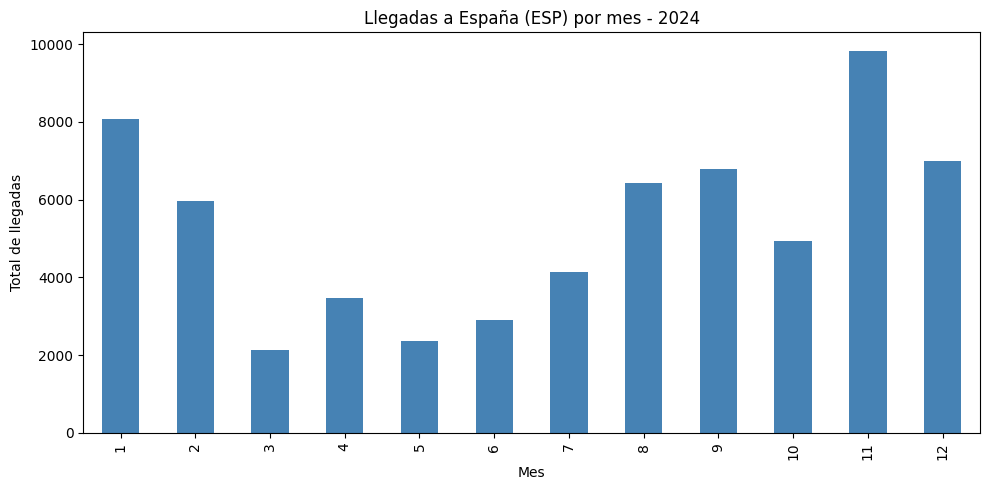

In [50]:
# Filtramos solo los registros de España (ESP) como destino.
df_esp = df[df['Destination'] == 'ESP']

# Agrupamos los datos de España por mes y sumamos las llegadas.
esp_por_mes = df_esp.groupby('Month')['Arrivals'].sum()

print("Llegadas a España por mes:")
print(esp_por_mes)

# Creamos una visualización simple con .plot().
# Pandas integra Matplotlib internamente, así que podemos graficar directamente.
# kind='bar' → gráfico de barras (ideal para datos categóricos/discretos como meses)
# title → título del gráfico
# ylabel → etiqueta del eje Y
# xlabel → etiqueta del eje X
# color → color de las barras
# figsize → tamaño del gráfico en pulgadas (ancho, alto)
import matplotlib.pyplot as plt
esp_por_mes.plot(
    kind='bar',
    title='Llegadas a España (ESP) por mes - 2024',
    ylabel='Total de llegadas',
    xlabel='Mes',
    color='steelblue',
    figsize=(10, 5)
)
plt.tight_layout()
plt.show()

### Ejercicio 8.3: Top países de origen por destino

In [51]:
# Para cada país de destino, encontramos los 3 principales países de origen.
# Paso a paso:
#   1) Agrupamos por Destino y Origen, sumando llegadas
#   2) Para cada destino, ordenamos y seleccionamos los top 3

# .groupby() con dos columnas + sum nos da el total por cada combinación.
totales = df.groupby(['Destination', 'Origin'])['Arrivals'].sum()

# .groupby(level=0) reagrupa por el primer nivel del índice (Destination).
# .nlargest(3) selecciona los 3 valores más grandes de cada grupo.
# Esto nos da, por cada destino, los 3 orígenes con más llegadas.
top3_por_destino = totales.groupby(level=0).nlargest(3)

# Limpiamos el índice duplicado que genera nlargest.
# droplevel(0) elimina el primer nivel redundante del MultiIndex.
top3_por_destino = top3_por_destino.droplevel(0)

print("Top 3 países de origen por cada destino:")
print("=" * 50)

# Iteramos por cada destino único para mostrar los resultados de forma clara.
for destino in df['Destination'].unique():
    if destino in top3_por_destino.index.get_level_values(0):
        datos = top3_por_destino.loc[destino]
        print(f"\n🏁 {destino}:")
        for origen, llegadas in datos.items():
            print(f"   {origen}: {llegadas:,} llegadas")

Top 3 países de origen por cada destino:

🏁 MLT:
   BGD: 113 llegadas
   SYR: 47 llegadas
   PAK: 31 llegadas

🏁 ITA:
   BGD: 14,284 llegadas
   SYR: 12,550 llegadas
   TUN: 7,741 llegadas

🏁 GRC:
   SYR: 21,278 llegadas
   AFG: 14,744 llegadas
   EGY: 6,768 llegadas

🏁 ESP:
   MLI: 17,453 llegadas
   SEN: 12,935 llegadas
   DZA: 10,039 llegadas

🏁 CYP:
   SYR: 4,220 llegadas
   AFG: 450 llegadas
   IRN: 375 llegadas

🏁 BGR:
   SYR: 5,245 llegadas
   AFG: 1,759 llegadas
   OOO: 1,169 llegadas


---

## 🏆 Ejercicio Final: Mini Análisis Completo

Realiza un análisis completo que incluya:

1. **Filtrado**: Selecciona datos del segundo semestre (julio-diciembre)
2. **Agrupación**: Agrupa por país de destino
3. **Cálculo**: Calcula total de llegadas y número de países de origen
4. **Ordenación**: Ordena por total de llegadas
5. **Visualización**: Crea una tabla resumen con los top 5 destinos

> 🔑 Este ejercicio integra todo lo aprendido: filtrado, groupby, agg, sort_values y visualización.

Registros en el segundo semestre: 891 de 1689 totales

📊 Top 5 destinos del segundo semestre 2024:
             Total_Llegadas  Paises_Origen
Destination                               
GRC                   41324             59
ITA                   40602             55
ESP                   39072             40
BGR                    6091              6
CYP                    1860             25


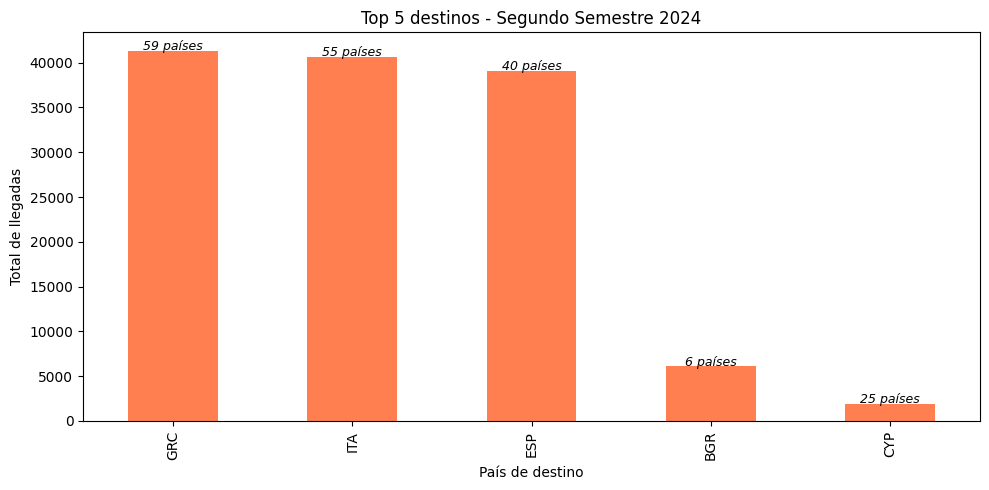


Resumen completo (6 destinos en el segundo semestre):


,Total_Llegadas,Paises_Origen
Destination,,
GRC,41324,59
ITA,40602,55
ESP,39072,40
BGR,6091,6
CYP,1860,25
MLT,170,7


In [52]:
# ============================
# PASO 1: FILTRADO
# ============================
# Seleccionamos solo los datos del segundo semestre (meses 7 a 12).
# Usamos >= 7 para filtrar julio en adelante.
df_s2 = df[df['Month'] >= 7]
print(f"Registros en el segundo semestre: {len(df_s2)} de {len(df)} totales")

# ============================
# PASO 2 y 3: AGRUPACIÓN Y CÁLCULO
# ============================
# Agrupamos por destino y calculamos DOS métricas:
#   - Total de llegadas: sum de 'Arrivals'
#   - Número de países de origen distintos: nunique de 'Origin'
# .agg() con un diccionario permite aplicar funciones diferentes a columnas diferentes.
resumen = df_s2.groupby('Destination').agg(
    Total_Llegadas=('Arrivals', 'sum'),
    Paises_Origen=('Origin', 'nunique')
)

# ============================
# PASO 4: ORDENACIÓN
# ============================
# Ordenamos por total de llegadas de mayor a menor.
resumen = resumen.sort_values('Total_Llegadas', ascending=False)

# ============================
# PASO 5: VISUALIZACIÓN
# ============================
# Mostramos los top 5 destinos como tabla resumen.
print("\n📊 Top 5 destinos del segundo semestre 2024:")
print("=" * 55)
top5 = resumen.head(5)
print(top5)

# Gráfico de barras del top 5 destinos.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
top5['Total_Llegadas'].plot(
    kind='bar',
    color='coral',
    ax=ax
)
ax.set_title('Top 5 destinos - Segundo Semestre 2024')
ax.set_ylabel('Total de llegadas')
ax.set_xlabel('País de destino')

# Añadimos el número de países de origen encima de cada barra.
for i, (idx, row) in enumerate(top5.iterrows()):
    ax.text(i, row['Total_Llegadas'] + 100, f"{row['Paises_Origen']} países",
            ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

print(f"\nResumen completo ({len(resumen)} destinos en el segundo semestre):")
resumen

---

## 💡 Recursos Adicionales

- [Documentación oficial de Pandas](https://pandas.pydata.org/docs/)
- [Pandas Cheat Sheet](https://pandas.pydata.org/Pandas_Cheat_Sheet.pdf)
- Revisa el notebook "Introducción a Pandas.ipynb" para ejemplos adicionales

---

## ✅ Checklist de Aprendizaje

Marca los conceptos que ya dominas:

- [ ] Cargar datos desde Excel
- [ ] Explorar información básica (info, shape, columns)
- [ ] Seleccionar columnas y filas
- [ ] Filtrar con condiciones
- [ ] Ordenar datos
- [ ] Crear nuevas columnas
- [ ] Agrupar y agregar datos
- [ ] Manejar valores nulos
- [ ] Realizar análisis integrados

---

**¡Buena suerte con los ejercicios!** 🚀